In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install torch
!pip install pytorch-lightning
!pip install pytorch-forecasting
!pip install pytorch-tabular shap
!pip install shap
!pip install stable-baselines3
!pip install "shimmy>=2.0"

In [2]:
!pip install tensorboard


**LIBRARIES**

In [3]:
# General libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# PyTorch & Lightning
import torch
import torch.nn as nn
from torch.optim import Adam
import lightning.pytorch as pl
# Pytorch Forecasting (TFT & utilities)
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet, GroupNormalizer, Baseline, QuantileLoss
# Reinforcement Learning (Stable Baselines3)
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
# Gym (for environment)
import gym
from gym import spaces
# Extra (for SB3 compatibility)
import shimmy  # Ensures Gym + Gymnasium compatibility

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**LOADING**

In [4]:
# Load datasets
sales_df = pd.read_csv("sales_train_validation.csv")
calendar_df = pd.read_csv("calendar.csv")
prices_df = pd.read_csv( "sell_prices.csv")

# Check shapes
print(f"Sales data shape: {sales_df.shape}")
print(f"Calendar data shape: {calendar_df.shape}")
print(f"Prices data shape: {prices_df.shape}")

# Quick look at data
print(sales_df.head())
print(calendar_df.head())
print(prices_df.head())

Sales data shape: (30490, 1919)
Calendar data shape: (1969, 14)
Prices data shape: (6841121, 4)
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  ...  d_1904  d_1905  d_1906  d_1907  d_1908  \
0       CA    0    0    0    0  ...       1       3       0       1       1   
1       CA    0    0    0    0  ...       0       0       0       0       0   
2       CA    0    0    0    0  ...       2       1       2       1       1   
3       CA    0    0    0    0  ...       1       0       5       4       1   
4       CA    0    0    0   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Filter by 1 store and top 30 item IDs
selected_store = 'CA_1'
selected_items = sales_df[sales_df['store_id'] == selected_store]['item_id'].unique()[:30]
sales_df_small = sales_df[
    (sales_df['store_id'] == selected_store) &
    (sales_df['item_id'].isin(selected_items))
].copy()

# Ensure date column is datetime
calendar_df['date'] = pd.to_datetime(calendar_df['date'])

# Get last 180 days
recent_dates = calendar_df['date'].sort_values().unique()[-180:]
recent_days = calendar_df[calendar_df['date'].isin(recent_dates)]['d'].unique().tolist()

# Only keep the sales columns for those days + identifier columns
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
available_days = [col for col in recent_days if col in sales_df_small.columns]
filtered_sales = sales_df_small[id_cols + available_days]

# Melt the sales data to long format
sales_long = pd.melt(
    filtered_sales,
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)

# Merge with calendar and price data
sales_calendar = sales_long.merge(calendar_df, how='left', on='d')
full_data = sales_calendar.merge(prices_df, how='left', on=['store_id', 'item_id', 'wm_yr_wk'])

# Fill missing sell_price within each item-store group
full_data['sell_price'] = full_data.groupby(['store_id', 'item_id'])['sell_price'].ffill().bfill()

print(f"Merged data shape: {full_data.shape}")
print(full_data.head())

Merged data shape: (3720, 22)
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id       d  sales       date  wm_yr_wk  ... month  year  event_name_1  \
0       CA  d_1790      3 2015-12-23     11547  ...    12  2015           NaN   
1       CA  d_1790      3 2015-12-23     11547  ...    12  2015           NaN   
2       CA  d_1790      2 2015-12-23     11547  ...    12  2015           NaN   
3       CA  d_1790      0 2015-12-23     11547  ...    12  2015           NaN   
4       CA  d_1790      3 2015-12-23     11547  ...    12  2015           NaN   

  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


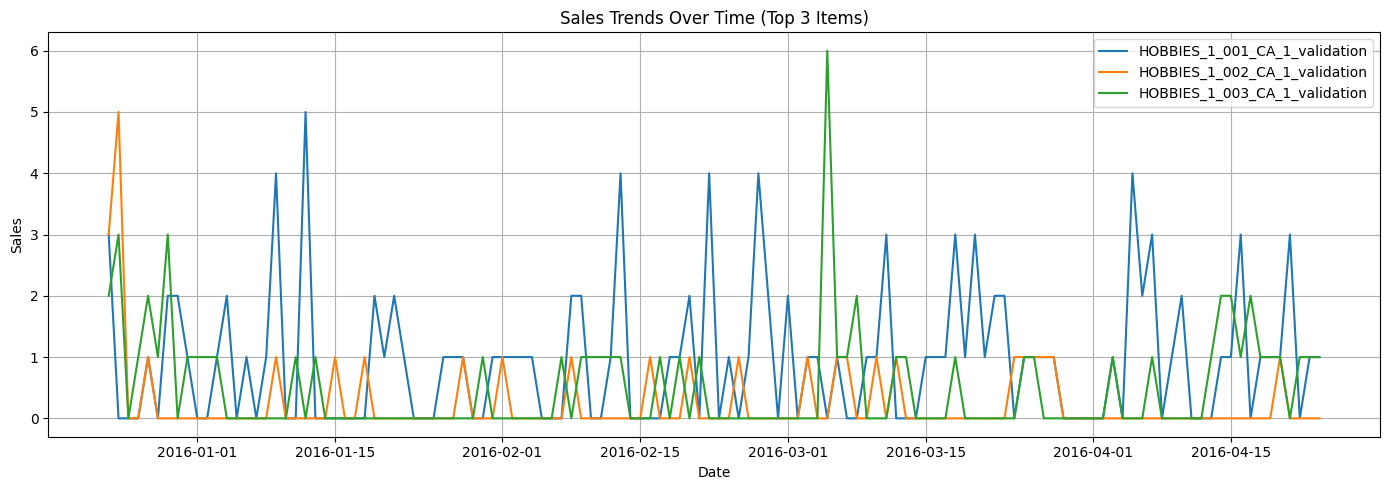

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


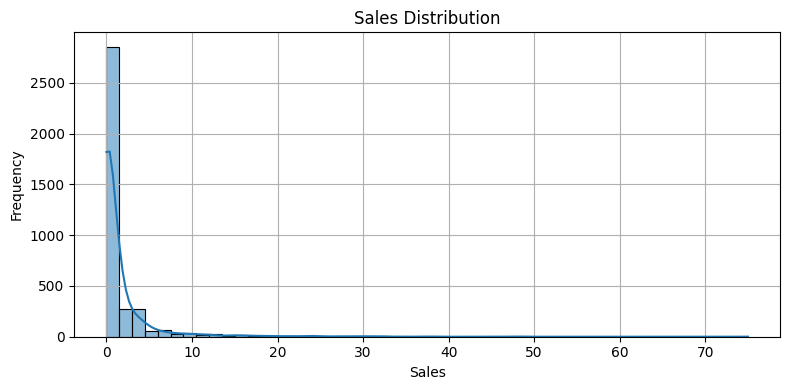

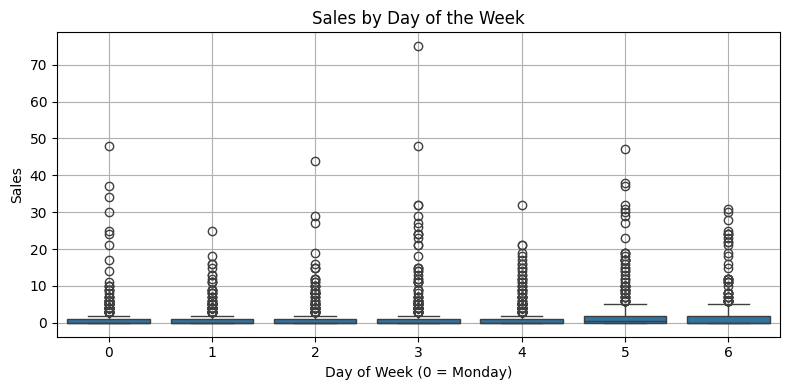

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


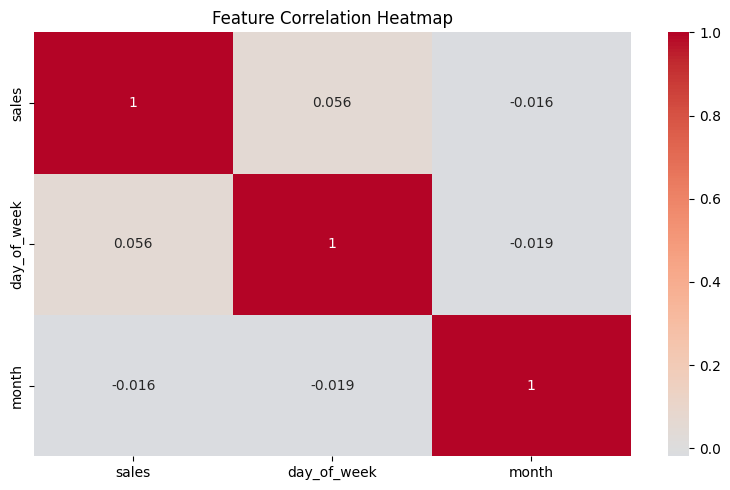

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'full_data' is already loaded
full_data["date"] = pd.to_datetime(full_data["date"])
full_data["day_of_week"] = full_data["date"].dt.dayofweek  # Monday=0
full_data["month"] = full_data["date"].dt.month

# 1. Sales Trends for Sample Items
sample_items = full_data["id"].unique()[:3]
sample_df = full_data[full_data["id"].isin(sample_items)]

plt.figure(figsize=(14, 5))
for item in sample_items:
    item_df = sample_df[sample_df["id"] == item]
    plt.plot(item_df["date"], item_df["sales"], label=item)
plt.title("Sales Trends Over Time (Top 3 Items)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Sales Distribution
plt.figure(figsize=(8, 4))
sns.histplot(full_data["sales"], bins=50, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Boxplot of Sales by Day of Week
plt.figure(figsize=(8, 4))
sns.boxplot(x="day_of_week", y="sales", data=full_data)
plt.title("Sales by Day of the Week")
plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Correlation Heatmap
numeric_cols = ["sales", "day_of_week", "month"]
corr = full_data[numeric_cols].corr()
plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Ensure 'date' is datetime
full_data['date'] = pd.to_datetime(full_data['date'])

# 2. Create a time index for TFT (days since first date)
full_data['time_idx'] = (full_data['date'] - full_data['date'].min()).dt.days

# 3. Sort for lag features
full_data = full_data.sort_values(by=['id', 'date'])

# 4. Create lag features
LAG_DAYS = [7]
for lag in LAG_DAYS:
    full_data[f'lag_{lag}'] = full_data.groupby('id')['sales'].shift(lag)

# 5. Create rolling mean features
ROLLING_WINDOWS = [7]
for window in ROLLING_WINDOWS:
    full_data[f'rolling_mean_{window}'] = (
        full_data.groupby('id')['sales']
        .shift(1)  # shift by 1 to avoid using current day's value
        .rolling(window)
        .mean()
        .reset_index(drop=True))

# 6. Create date-based features
full_data['day_of_week'] = full_data['date'].dt.dayofweek
full_data['week_of_year'] = full_data['date'].dt.isocalendar().week.astype('int16')
full_data['month'] = full_data['date'].dt.month
full_data['year'] = full_data['date'].dt.year

# Lag features
full_data["lag_1"] = full_data.groupby("id")["sales"].shift(1)
full_data["lag_7"] = full_data.groupby("id")["sales"].shift(7)
full_data["lag_14"] = full_data.groupby("id")["sales"].shift(14)

# Rolling means
full_data["rolling_mean_7"] = (
    full_data.groupby("id")["sales"].transform(lambda x: x.shift(1).rolling(7).mean())
)

full_data["rolling_mean_14"] = (
    full_data.groupby("id")["sales"].transform(lambda x: x.shift(1).rolling(14).mean())
)

# Extra time features
full_data["day_of_month"] = full_data["date"].dt.day
full_data["week_of_year"] = full_data["date"].dt.isocalendar().week.astype(int)
full_data["is_weekend"] = full_data["date"].dt.dayofweek.isin([5, 6]).astype(int)


# 7. Encode categorical features
cat_cols = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
for col in cat_cols:
    full_data[col] = full_data[col].astype(str)  # Optionally: use LabelEncoder

# 8. Filter IDs with enough data history (>= 30 days)
min_required_days = 30
id_counts = full_data['id'].value_counts()
valid_ids = id_counts[id_counts > min_required_days].index
full_data = full_data[full_data['id'].isin(valid_ids)].copy()

# Print check
print(f"✅ Final feature-engineered shape: {full_data.shape}")
print(full_data[['sales', 'lag_7', 'rolling_mean_7', 'day_of_week', 'month']].head())

✅ Final feature-engineered shape: (3720, 32)
     sales  lag_7  rolling_mean_7  day_of_week  month
0        3    NaN             NaN            2     12
30       0    NaN             NaN            3     12
60       0    NaN             NaN            4     12
90       0    NaN             NaN            5     12
120      1    NaN             NaN            6     12


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
# Convert relevant categorical columns to string
categorical_columns = [
    "item_id", "store_id", "id",
    "event_name_1", "event_type_1",
    "day_of_week" ] # corrected from "weekday"]
for col in categorical_columns:
    if col in full_data.columns:
        full_data[col] = full_data[col].astype(str)

print("✅ Cleaned and converted all categorical columns to string type")

✅ Cleaned and converted all categorical columns to string type


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
from lightning.pytorch import seed_everything
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

seed_everything(42, workers=True)

required_cols = [
    "sales",
    "sell_price",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "month",
    "year",
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "is_weekend",
]

full_data = full_data.dropna(subset=required_cols).copy()

print("Cleaned full_data shape:", full_data.shape)

max_prediction_length = 7
training_cutoff = full_data["time_idx"].max() - max_prediction_length

training = TimeSeriesDataSet(
    full_data[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="sales",
    group_ids=["id"],
    max_encoder_length=30,
    max_prediction_length=max_prediction_length,
    static_categoricals=["item_id", "store_id", "dept_id", "cat_id", "state_id"],
    time_varying_known_reals=[
        "time_idx",
        "month",
        "year",
        "day_of_month",
        "week_of_year",
        "is_weekend",
    ],
    time_varying_known_categoricals=["day_of_week"],
    time_varying_unknown_reals=[
        "sales",
        "lag_1",
        "lag_7",
        "rolling_mean_7",
        "sell_price",
      ],
    target_normalizer=GroupNormalizer(groups=["id"]),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    full_data,
    predict=True,
    stop_randomization=True
)

train_dataloader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=64, num_workers=0)

print("✅ Training and validation dataloaders created successfully")

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Cleaned full_data shape: (3510, 32)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Training and validation dataloaders created successfully


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
# TabTransformer dataset for one-step sales prediction
tab_data = full_data.copy()

tab_features_cat = ["item_id", "store_id", "dept_id", "cat_id", "state_id", "day_of_week"]
tab_features_num = [
    "sell_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "month",
    "year",
    "time_idx",
    "day_of_month",
    "week_of_year",
    "is_weekend",
]

target_col = "sales"

# Keep only needed columns and drop rows with missing values
tab_data = tab_data[tab_features_cat + tab_features_num + [target_col]].dropna().reset_index(drop=True).copy()

# Train/valid split
split_idx = int(len(tab_data) * 0.8)
tab_train = tab_data.iloc[:split_idx].copy()
tab_valid = tab_data.iloc[split_idx:].copy()

print("tab_train shape:", tab_train.shape)
print("tab_valid shape:", tab_valid.shape)
tab_train.head()

tab_train shape: (2640, 19)
tab_valid shape: (660, 19)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,item_id,store_id,dept_id,cat_id,state_id,day_of_week,sell_price,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,month,year,time_idx,day_of_month,week_of_year,is_weekend,sales
0,HOBBIES_1_001,CA_1,HOBBIES_1,HOBBIES,CA,2,8.26,0.0,2.0,3.0,0.857143,0.857143,1,2016,14,6,1,0,1
1,HOBBIES_1_001,CA_1,HOBBIES_1,HOBBIES,CA,3,8.26,1.0,1.0,0.0,0.714286,0.714286,1,2016,15,7,1,0,0
2,HOBBIES_1_001,CA_1,HOBBIES_1,HOBBIES,CA,4,8.26,0.0,0.0,0.0,0.571429,0.714286,1,2016,16,8,1,0,1
3,HOBBIES_1_001,CA_1,HOBBIES_1,HOBBIES,CA,5,8.26,1.0,0.0,0.0,0.714286,0.785714,1,2016,17,9,1,1,4
4,HOBBIES_1_001,CA_1,HOBBIES_1,HOBBIES,CA,6,8.26,4.0,1.0,1.0,1.285714,1.071429,1,2016,18,10,1,1,0


In [11]:
# Make continuous columns float to avoid dtype warnings
for col in tab_features_num + [target_col]:
    tab_train[col] = tab_train[col].astype("float32")
    tab_valid[col] = tab_valid[col].astype("float32")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
from pytorch_tabular import TabularModel
from pytorch_tabular.models import TabTransformerConfig
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig

data_config = DataConfig(
    target=[target_col],
    continuous_cols=tab_features_num,
    categorical_cols=tab_features_cat,
)

trainer_config = TrainerConfig(
    auto_lr_find=False,
    batch_size=256,
    max_epochs=30,
)

optimizer_config = OptimizerConfig()

model_config = TabTransformerConfig(
    task="regression",
    learning_rate=1e-3,
    metrics=["mean_absolute_error"],   # changed
)

tab_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

tab_model.fit(train=tab_train, validation=tab_valid)

/usr/local/lib/python3.12/dist-packages/torch/jit/_script.py:1480: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-03-21 23:32:42,192 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-03-21 23:32:42,214 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-03-21 23:32:42,223 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for regression task
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcn

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ TabTransformerBackbone │  271 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer       │  1.4 K │ train │     0 │
│ 2 │ _head            │ LinearHead             │    205 │ train │     0 │
│ 3 │ loss             │ MSELoss                │      0 │ train │     0 │
└───┴──────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 272 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 272 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 131                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is 
set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches 
(11) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

2026-03-21 23:32:57,073 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-03-21 23:32:57,076 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


In [13]:
tab_preds = tab_model.predict(tab_valid)
tab_preds.head()

/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_model.py:1467: DeprecationWarning: `include_input_features` will be deprecated in the next release. Please add index columns to the test dataframe if you want to retain some features like the key or id
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,sales_prediction
2640,1.181887
2641,1.788114
2642,1.549373
2643,2.174731
2644,1.899265


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = tab_valid[target_col].values
y_pred = tab_preds[f"{target_col}_prediction"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"TabTransformer MAE: {mae:.3f}")
print(f"TabTransformer RMSE: {rmse:.3f}")

TabTransformer MAE: 2.110
TabTransformer RMSE: 3.796


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/tmp/ipykernel_16003/2166611867.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_valid)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


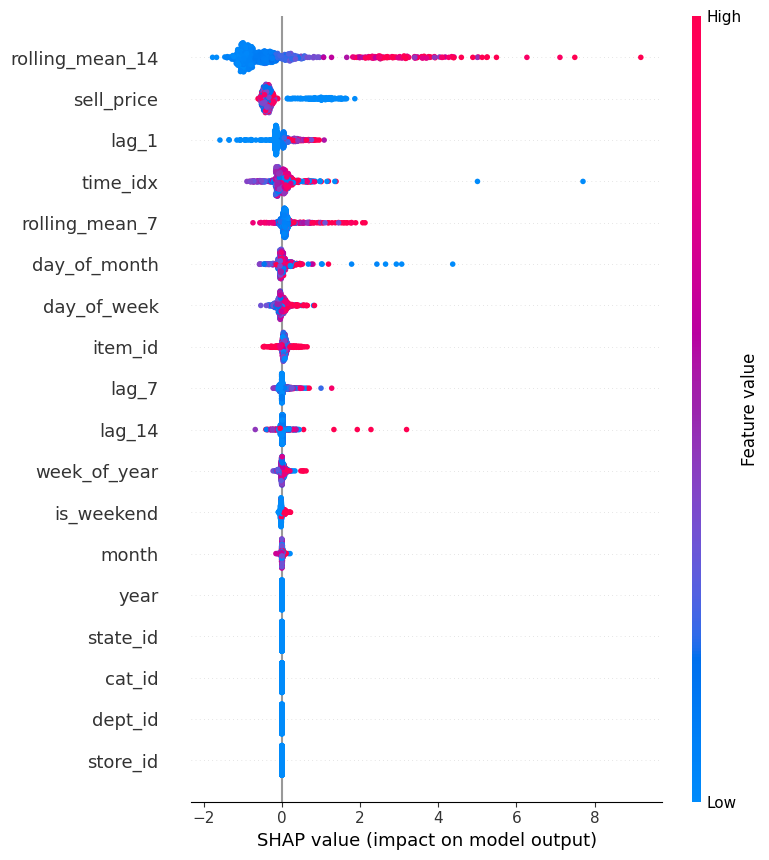

In [15]:
import shap
from sklearn.ensemble import RandomForestRegressor

# Encode categoricals for surrogate SHAP model
shap_data = tab_data.copy()
for col in tab_features_cat:
    shap_data[col] = shap_data[col].astype("category").cat.codes

X = shap_data[tab_features_cat + tab_features_num]
y = shap_data[target_col]

split_idx = int(len(shap_data) * 0.8)
X_train, X_valid = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_valid = y.iloc[:split_idx], y.iloc[split_idx:]

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_valid)

shap.summary_plot(shap_values, X_valid)

In [16]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

logger = TensorBoardLogger("lightning_logs", name="tft_m5_model")

early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=4,
    verbose=True,
    mode="min"
)

lr_logger = LearningRateMonitor(logging_interval="epoch")
checkpoint_callback = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    output_size=7,
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=2
)

trainer = pl.Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback, checkpoint_callback],
    logger=logger,
    enable_progress_bar=True
)

trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

print("✅ TFT training complete.")






/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    369 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    240 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.4 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  8.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  4.6 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 30.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 512                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

...

/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:2315: DeprecationWarning: __array_wrap__ must 
accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dx = [convert(x0 + ddx) - x for ddx in dx]

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

INFO: Monitored metric val_loss did not improve in the last 4 records. Best score: 0.691. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 4 records. Best score: 0.691. Signaling Trainer to stop.


✅ TFT training complete.


In [17]:
from pytorch_forecasting.metrics import SMAPE
import torch

best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

predictions = best_tft.predict(val_dataloader)
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])

min_len = min(predictions.shape[0], actuals.shape[0])
predictions = predictions[:min_len]
actuals = actuals[:min_len]

smape = SMAPE()(predictions, actuals)
print(f"✅ SMAPE on validation set: {smape:.3f}")

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


✅ SMAPE on validation set: 1.532


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


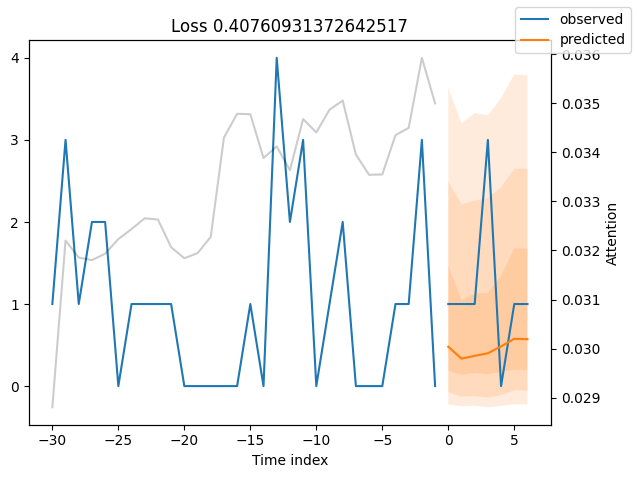

In [18]:
import matplotlib.pyplot as plt

# Get raw prediction output safely
prediction_output = best_tft.predict(val_dataloader, mode="raw", return_x=True)

# Handle different pytorch-forecasting return formats
if isinstance(prediction_output, tuple):
    raw_predictions = prediction_output[0]
    x = prediction_output[1]
else:
    raw_predictions = prediction_output.output
    x = prediction_output.x

# Plot one example prediction
best_tft.plot_prediction(x, raw_predictions, idx=0, add_loss_to_title=True)
plt.show()

In [19]:
class PricingEnv(gym.Env):
    def __init__(self, demand_data, cost_price=1.0, price_points=None, max_inventory=200):
        super(PricingEnv, self).__init__()
        self.demand_data = np.array(demand_data, dtype=np.float32)
        self.cost_price = cost_price
        self.price_points = price_points if price_points is not None else np.linspace(1.0, 10.0, 10)
        self.max_inventory = max_inventory

        self.action_space = spaces.Discrete(len(self.price_points))
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0], dtype=np.float32),
            high=np.array([self.max_inventory, np.max(self.demand_data), len(self.demand_data)], dtype=np.float32),
            dtype=np.float32
        )
        self.reset()

    def reset(self):
        self.current_step = 0
        self.inventory = self.max_inventory
        return self._get_obs()

    def _get_obs(self):
        demand = self.demand_data[min(self.current_step, len(self.demand_data) - 1)]
        return np.array([
            self.inventory,
            demand,
            self.current_step
        ], dtype=np.float32)

    def step(self, action):
        price = self.price_points[int(action)]
        demand = self.demand_data[self.current_step]
        adjusted_demand = max(0, demand * (1 - 0.05 * (price - 1.0)))
        sold = min(adjusted_demand, self.inventory)
        revenue = price * sold
        cost = self.cost_price * sold
        inventory_penalty = 0.01 * self.inventory
        reward = revenue - cost - inventory_penalty

        self.inventory -= sold
        self.current_step += 1
        done = self.current_step >= len(self.demand_data) or self.inventory <= 0

        obs = self._get_obs() if not done else np.array([self.inventory, 0, self.current_step], dtype=np.float32)
        return obs, reward, done, {}

In [20]:
import gym
from gym import spaces
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# Sample demand data
sample_item_id = full_data['id'].value_counts().index[0]
sample_demand = full_data[full_data['id'] == sample_item_id]['sales'].values[:120]

# Initialize environment
env = PricingEnv(
    demand_data=sample_demand,
    cost_price=1.0,
    price_points=np.linspace(1.0, 10.0, 10),
    max_inventory=200
)

vec_env = DummyVecEnv([lambda: env])
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=True, clip_obs=10.0)

ppo_agent = PPO("MlpPolicy", vec_env, verbose=1)
ppo_agent.learn(total_timesteps=10000)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------
| time/              |      |
|    fps             | 1066 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 981         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.014073738 |
|    clip_fraction        | 0.0977      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.29       |
|    explained_variance   | -0.297      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.97        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0126     |
|    value_loss           | 0.266       |
-----------------------------------------
----------------------------------

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:48: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return conv.wrap(result, to_scalar=False)
/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:2315: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dx = [convert(x0 + ddx) - x for ddx in dx]
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:48: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return conv.wrap(result, to_scalar=False)
/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:2315: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dx = [convert(x0 + ddx) - x for ddx i

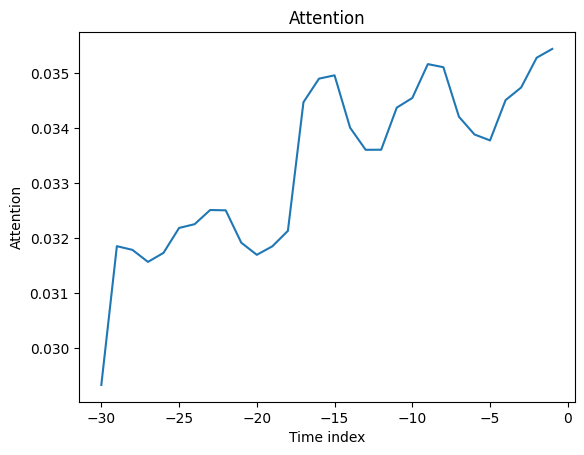

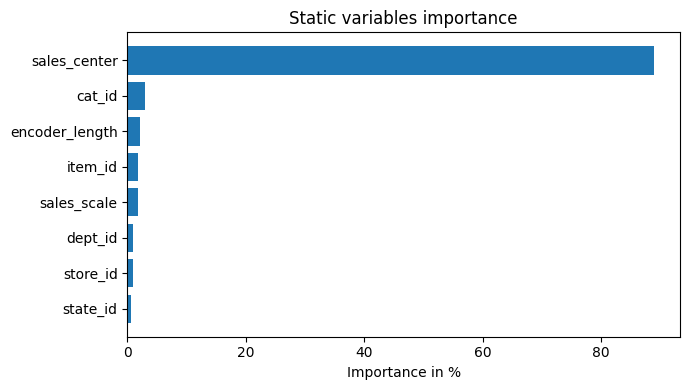

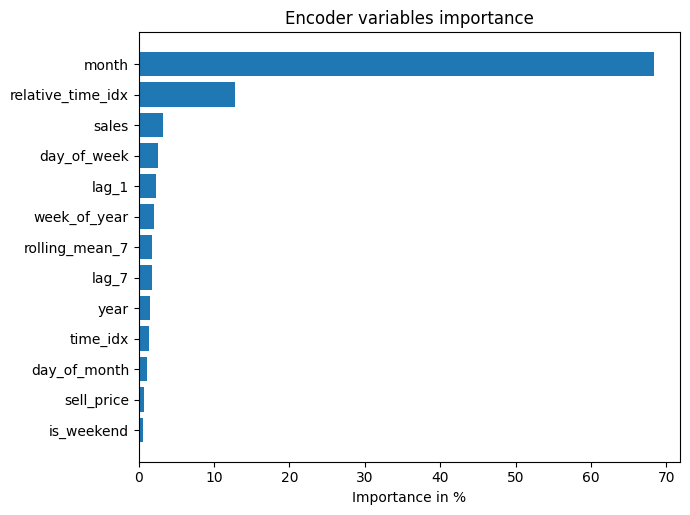

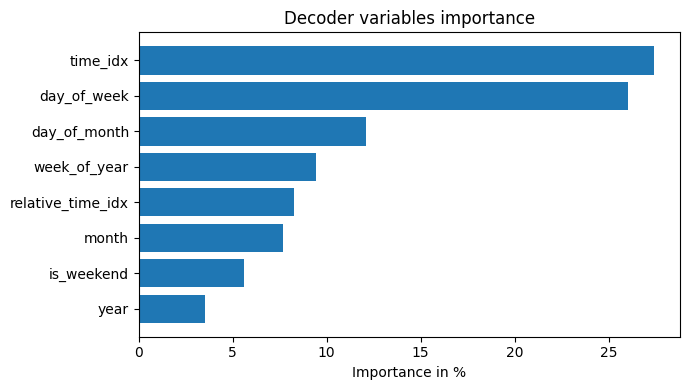

In [21]:
# TFT attention-based interpretability
interpretation = best_tft.interpret_output(raw_predictions, reduction="sum")
best_tft.plot_interpretation(interpretation)
plt.show()

In [22]:
obs = vec_env.reset()
total_rewards = []
prices = []
demands = []

for _ in range(len(sample_demand)):
    action, _states = ppo_agent.predict(obs)
    price = env.price_points[int(action[0])]
    prices.append(price)

    obs, reward, done, info = vec_env.step(action)
    total_rewards.append(float(reward[0]))

    demand = env.demand_data[min(env.current_step - 1, len(env.demand_data) - 1)]
    demands.append(float(demand))

    if done[0]:
        break

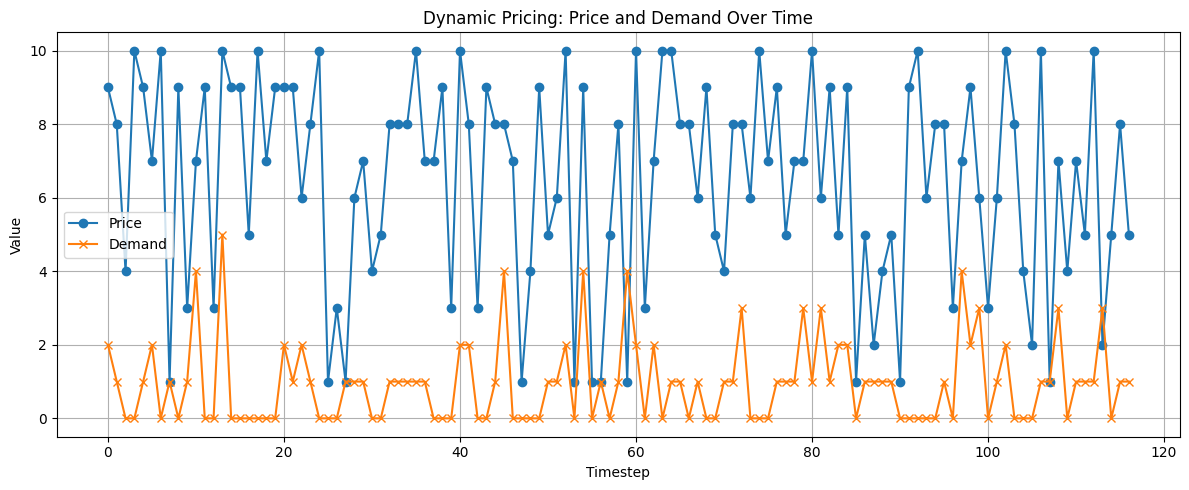

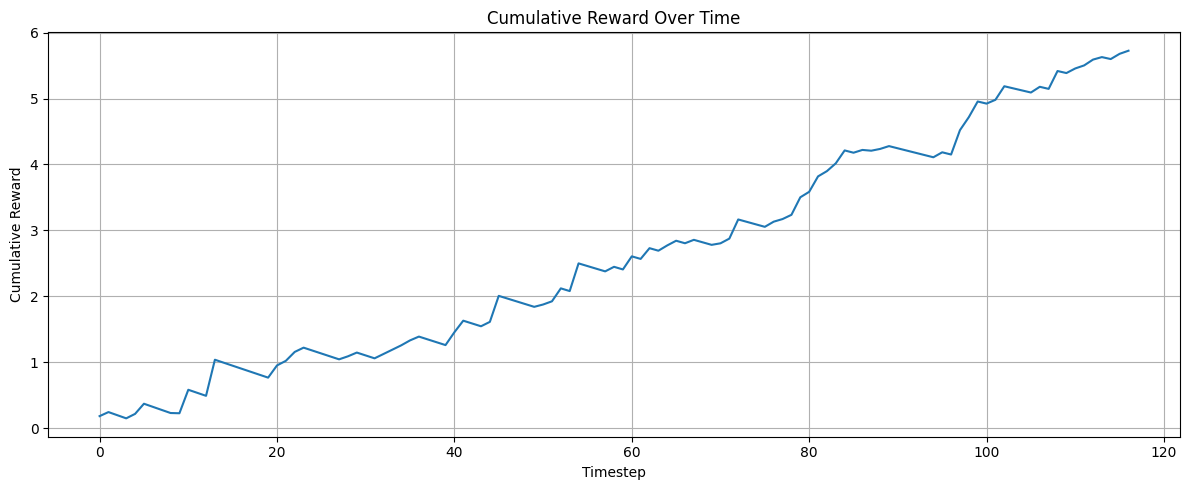

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 5))
plt.plot(prices, label="Price", marker='o')
plt.plot(demands, label="Demand", marker='x')
plt.title("Dynamic Pricing: Price and Demand Over Time")
plt.xlabel("Timestep")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(np.cumsum(total_rewards))
plt.title("Cumulative Reward Over Time")
plt.xlabel("Timestep")
plt.ylabel("Cumulative Reward")
plt.grid(True)
plt.tight_layout()
plt.show()